# Traffic Light Classification using VGG16 Transfer Learning

## 1. Import Libraries

In [54]:
import os
import random
import zipfile
import shutil

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


## 2. Reproducibility Settings

I am using seeds to make the results more consistent across runs.

In [55]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 3. Extract Dataset

The expected dataset structure is:

```text
traffic/
    Green/
    Red/
```

In [56]:
ZIP_PATH = 'traffic.zip'
DATA_DIR = 'traffic'

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall('.')
print('Dataset extracted successfully.')

print('Dataset folders:', os.listdir(DATA_DIR))

Dataset extracted successfully.
Dataset folders: ['Green', '.DS_Store', 'Red']


## 4. Load Images using OpenCV

OpenCV loads images in **BGR**, while VGG16 preprocessing expects images in the usual **RGB** order.

In [57]:
IMG_SIZE = 224

X = []
Z = []

GREEN_DIR = os.path.join(DATA_DIR, 'Green')
RED_DIR = os.path.join(DATA_DIR, 'Red')

def assign_label(img, traffic_light_type):
    return traffic_light_type

def make_train_data(traffic_light_type, DIR):
    for img_name in os.listdir(DIR):
        img_path = os.path.join(DIR, img_name)

        img = cv2.imread(img_path)

        # convert to RGB for VGG16
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Resize to VGG16 input size
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        X.append(img)
        Z.append(assign_label(img, traffic_light_type))


make_train_data('Green', GREEN_DIR)
make_train_data('Red', RED_DIR)

X = np.array(X, dtype='float32') 
Z = np.array(Z)

print('X shape:', X.shape)
print('Z shape:', Z.shape)
print('Classes and counts:', pd.Series(Z).value_counts().to_dict())

X shape: (2482, 224, 224, 3)
Z shape: (2482,)
Classes and counts: {'Green': 1296, 'Red': 1186}


## 5. Check Loaded Images

Confirming that images are displayed with the correct colour channels after converting from BGR to RGB.

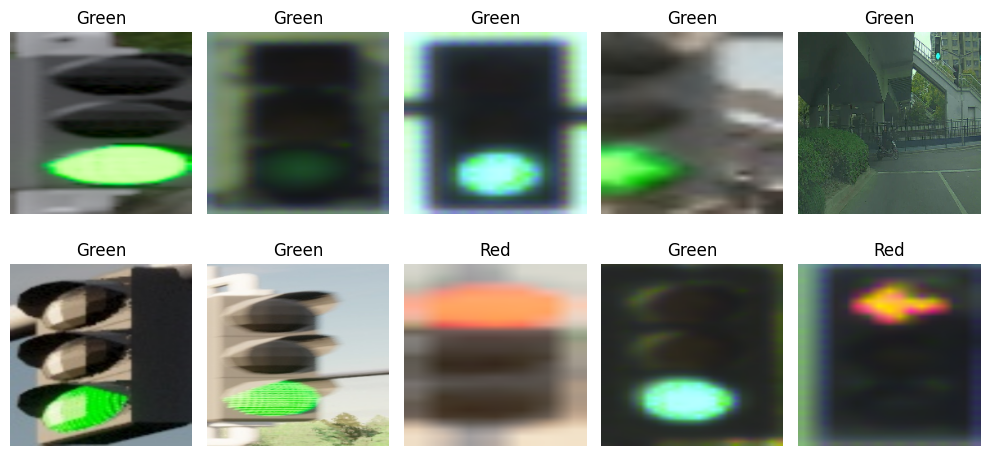

In [58]:
plt.figure(figsize=(10, 5))
for i in range(10):
    idx = random.randint(0, len(X) - 1)
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[idx].astype('uint8'))
    plt.title(Z[idx])
    plt.axis('off')
plt.tight_layout()
plt.show()

## 6. Encode Labels

In [59]:
le = LabelEncoder()
y_integer = le.fit_transform(Z)
y = to_categorical(y_integer,2)

class_names = list(le.classes_)
print('Class names:', class_names)
print('Encoded label example:', Z[0], '->', y_integer[0], '->', y[0])

Class names: [np.str_('Green'), np.str_('Red')]
Encoded label example: Green -> 0 -> [1. 0.]


## 7. Stratified Train/Validation/Test Split

The dataset is small, so stratification is important to keep Green and Red balanced in each split.

Split used:

- 70% training
- 15% validation
- 15% testing

In [60]:
X_train, X_temp, y_train, y_temp, y_train_int, y_temp_int = train_test_split(
    X,
    y,
    y_integer,
    test_size=0.30,
    random_state=SEED,
    stratify=y_integer
)

X_val, X_test, y_val, y_test, y_val_int, y_test_int = train_test_split(
    X_temp,
    y_temp,
    y_temp_int,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp_int
)

print('Training:', X_train.shape, pd.Series(y_train_int).value_counts().sort_index().to_dict())
print('Validation:', X_val.shape, pd.Series(y_val_int).value_counts().sort_index().to_dict())
print('Testing:', X_test.shape, pd.Series(y_test_int).value_counts().sort_index().to_dict())

Training: (1737, 224, 224, 3) {0: 907, 1: 830}
Validation: (372, 224, 224, 3) {0: 194, 1: 178}
Testing: (373, 224, 224, 3) {0: 195, 1: 178}


## 8. Helper Functions

In [61]:
def plot_history(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()


def evaluate_model(model, X_test, y_test, model_name):
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f'{model_name} test accuracy: {test_acc:.4f}')
    print(f'{model_name} test loss: {test_loss:.4f}')

    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)

    print(f'Classification report for {model_name}:')
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

    return test_loss, test_acc, y_true, y_pred, y_pred_probs

## 9. Data Augmentation

Data augmentation is applied inside the model, so it runs only during training.

In [62]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
], name='data_augmentation')

# Model 1: Frozen VGG16 + Data Augmentation


In [63]:
base_model_1 = VGG16(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model_1.trainable = False

model_1 = Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    data_augmentation,
    layers.Lambda(preprocess_input),
    base_model_1,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.25),
    layers.Dense(2, activation='softmax')
])

model_1.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,610 (56.38 MB)

 Trainable params: 65,922 (257.51 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [21]:
callbacks_1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
]

history_1 = model_1.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=4,
    batch_size=16,
    callbacks=callbacks_1,
    verbose=1
)

Epoch 1/4
109/109 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.9634 - loss: 0.1107 - val_accuracy: 0.9839 - val_loss: 0.0614
Epoch 2/4
109/109 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.9731 - loss: 0.0990 - val_accuracy: 0.9785 - val_loss: 0.0524
Epoch 3/4
109/109 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.9710 - loss: 0.0858 - val_accuracy: 0.9839 - val_loss: 0.0482
Epoch 4/4
109/109 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.9802 - loss: 0.0548 - val_accuracy: 0.9839 - val_loss: 0.0453


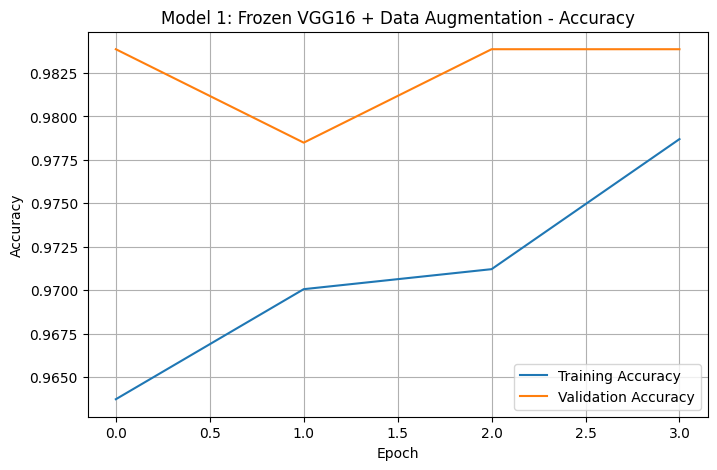

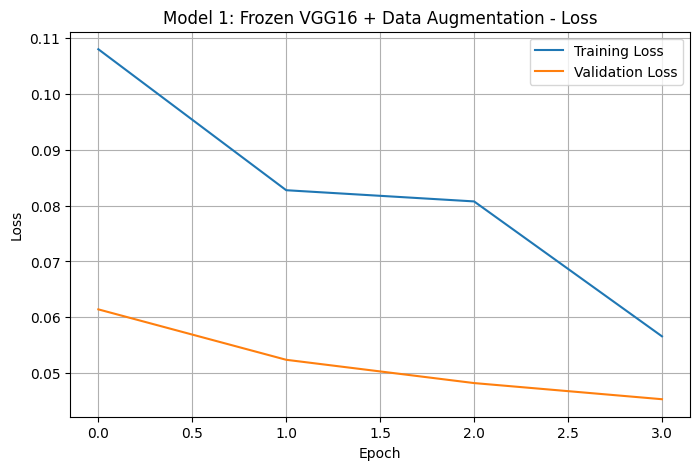

Model 1 VGG16 Baseline test accuracy: 0.9786
Model 1 VGG16 Baseline test loss: 0.0486
Classification report for Model 1 VGG16 Baseline:
              precision    recall  f1-score   support

       Green       0.99      0.96      0.98       195
         Red       0.96      0.99      0.98       178

    accuracy                           0.98       373
   macro avg       0.98      0.98      0.98       373
weighted avg       0.98      0.98      0.98       373



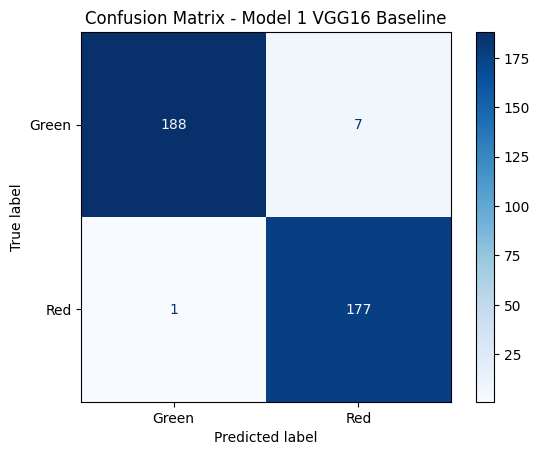

In [22]:
plot_history(history_1, 'Model 1: Frozen VGG16 + Data Augmentation')
model_1_loss, model_1_acc, y_true_1, y_pred_1, y_pred_probs_1 = evaluate_model(
    model_1, X_test, y_test, 'Model 1 VGG16 Baseline'
)

# Model 2: VGG16 + Stronger Regularisation

Improvement Method 1 adds stronger regularisation:

- L2 regularisation
- Higher dropout

This aims to reduce overfitting and improve generalisation.

In [23]:
base_model_2 = VGG16(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model_2.trainable = False

model_2 = Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    data_augmentation,
    layers.Lambda(preprocess_input),
    base_model_2,
    layers.GlobalAveragePooling2D(),
    layers.Dense(
        128,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),
    layers.Dropout(0.50),
    layers.Dense(2, activation='softmax')
])

model_2.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,610 (56.38 MB)

 Trainable params: 65,922 (257.51 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [39]:
callbacks_2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True
    )
]

history_2 = model_2.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=16,
    callbacks=callbacks_2,
    verbose=1
)

Epoch 1/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.9314 - loss: 0.3840 - val_accuracy: 0.9704 - val_loss: 0.2803
Epoch 2/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.9488 - loss: 0.3389 - val_accuracy: 0.9731 - val_loss: 0.2715
Epoch 3/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.9563 - loss: 0.3341 - val_accuracy: 0.9785 - val_loss: 0.2531
Epoch 4/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.9632 - loss: 0.3284 - val_accuracy: 0.9785 - val_loss: 0.2537
Epoch 5/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.9692 - loss: 0.2827 - val_accuracy: 0.9812 - val_loss: 0.2437
Epoch 6/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.9610 - loss: 0.3020 - val_accuracy: 0.9866 - val_loss: 0.2352
Epoch 7/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.9709 - loss: 0.2798 - val_accuracy: 0.9892 - val_loss: 0.2290
Epoch 8/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.9701 - loss: 0.2795 - val_accu

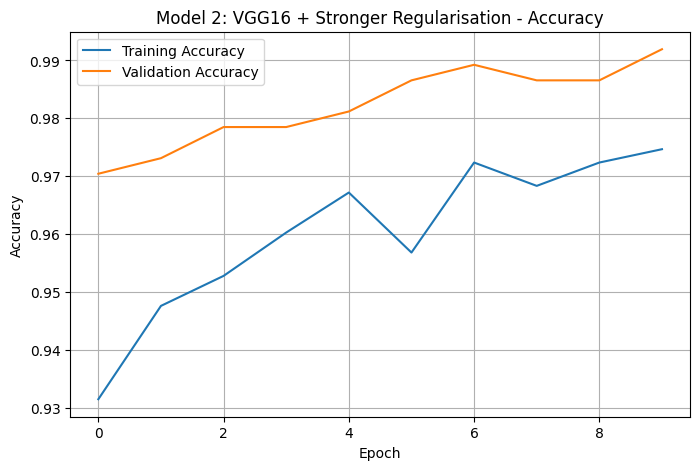

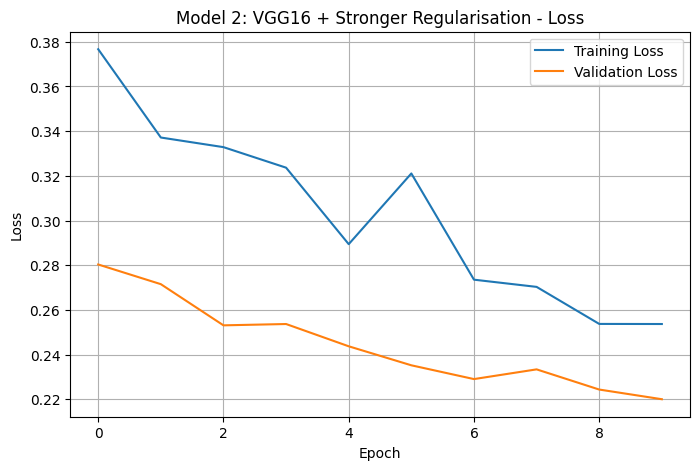

Model 2 Regularised VGG16 test accuracy: 0.9893
Model 2 Regularised VGG16 test loss: 0.2232
Classification report for Model 2 Regularised VGG16:
              precision    recall  f1-score   support

       Green       0.99      0.98      0.99       195
         Red       0.98      0.99      0.99       178

    accuracy                           0.99       373
   macro avg       0.99      0.99      0.99       373
weighted avg       0.99      0.99      0.99       373



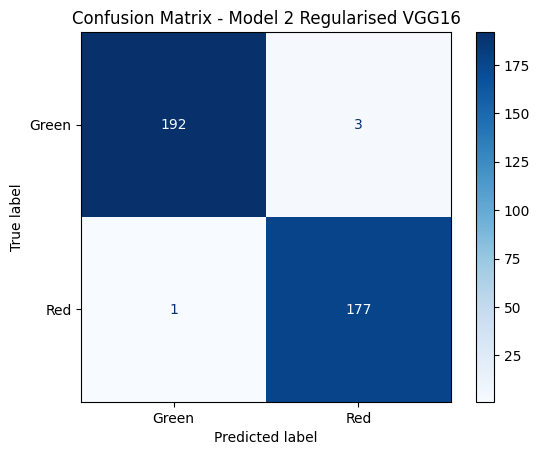

In [40]:
plot_history(history_2, 'Model 2: VGG16 + Stronger Regularisation')
model_2_loss, model_2_acc, y_true_2, y_pred_2, y_pred_probs_2 = evaluate_model(
    model_2, X_test, y_test, 'Model 2 Regularised VGG16'
)

# Model 3: Classification Threshold Tuning

Getting validation probabilities

In [26]:
val_probs = model_1.predict(X_val)

y_val_true = np.argmax(y_val, axis=1)

print(val_probs[:5])
print(y_val_true[:5])

12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step
[[1.7114053e-05 9.9998289e-01]
 [9.9812371e-01 1.8763267e-03]
 [5.0096735e-03 9.9499035e-01]
 [7.0345014e-02 9.2965496e-01]
 [9.9994802e-01 5.1986761e-05]]
[1 0 1 1 0]


Testing different Red thresholds

In [27]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

threshold_results = []

for threshold in np.arange(0.30, 0.76, 0.05):

    # Predict Red only if Red probability is at least the threshold.
    # Otherwise predict Green.
    y_val_pred = np.where(val_probs[:, 1] >= threshold, 1, 0)

    acc = accuracy_score(y_val_true, y_val_pred)
    precision = precision_score(y_val_true, y_val_pred, average="macro", zero_division=0)
    recall = recall_score(y_val_true, y_val_pred, average="macro", zero_division=0)
    macro_f1 = f1_score(y_val_true, y_val_pred, average="macro")

    cm = confusion_matrix(y_val_true, y_val_pred)

    threshold_results.append({
        "Red Threshold": round(threshold, 2),
        "Validation Accuracy": round(acc, 4),
        "Validation Precision": round(precision, 4),
        "Validation Recall": round(recall, 4),
        "Validation Macro F1": round(macro_f1, 4),
        "Green predicted as Red": cm[0, 1],
        "Red predicted as Green": cm[1, 0]
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,Red Threshold,Validation Accuracy,Validation Precision,Validation Recall,Validation Macro F1,Green predicted as Red,Red predicted as Green
0,0.30,0.9785,0.9783,0.9791,0.9785,7,1
1,0.35,0.9785,0.9783,0.9791,0.9785,7,1
2,0.40,0.9839,0.9836,0.9843,0.9839,5,1
3,0.45,0.9812,0.9810,0.9815,0.9812,5,2
4,0.50,0.9839,0.9837,0.9841,0.9838,4,2
5,0.55,0.9839,0.9837,0.9841,0.9838,4,2
6,0.60,0.9812,0.9811,0.9813,0.9812,4,3
7,0.65,0.9866,0.9867,0.9864,0.9865,2,3
8,0.70,0.9866,0.9870,0.9862,0.9865,1,4
9,0.75,0.9866,0.9870,0.9862,0.9865,1,4


Selecting the best threshold

In [28]:
best_threshold_row = threshold_df.sort_values(
    by=["Validation Macro F1", "Validation Accuracy"],
    ascending=False
).iloc[0]

best_threshold = best_threshold_row["Red Threshold"]

print("Best threshold:")
print(best_threshold_row)

Best threshold:
Red Threshold             0.6500
Validation Accuracy       0.9866
Validation Precision      0.9867
Validation Recall         0.9864
Validation Macro F1       0.9865
Green predicted as Red    2.0000
Red predicted as Green    3.0000
Name: 7, dtype: float64


Applying the threshold to the test set

In [29]:
test_probs = model_1.predict(X_test)

y_test_true = np.argmax(y_test, axis=1)

y_test_pred_threshold = np.where(test_probs[:, 1] >= best_threshold, 1, 0)

threshold_test_accuracy = accuracy_score(y_test_true, y_test_pred_threshold)
threshold_test_precision = precision_score(y_test_true, y_test_pred_threshold, average="macro", zero_division=0)
threshold_test_recall = recall_score(y_test_true, y_test_pred_threshold, average="macro", zero_division=0)
threshold_test_macro_f1 = f1_score(y_test_true, y_test_pred_threshold, average="macro")

print(f"Best Red threshold: {best_threshold}")
print(f"Threshold-tuned test accuracy: {threshold_test_accuracy:.4f}")
print(f"Threshold-tuned macro precision: {threshold_test_precision:.4f}")
print(f"Threshold-tuned macro recall: {threshold_test_recall:.4f}")
print(f"Threshold-tuned macro F1-score: {threshold_test_macro_f1:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step
Best Red threshold: 0.65
Threshold-tuned test accuracy: 0.9866
Threshold-tuned macro precision: 0.9863
Threshold-tuned macro recall: 0.9869
Threshold-tuned macro F1-score: 0.9866


Plot threshold performance

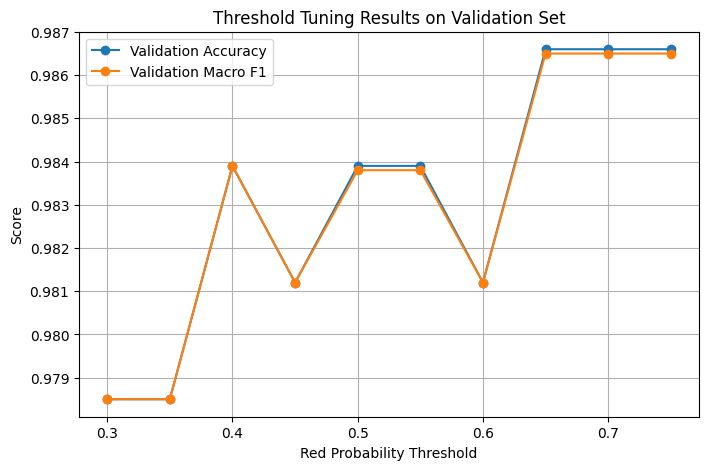

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["Red Threshold"],
    threshold_df["Validation Accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.plot(
    threshold_df["Red Threshold"],
    threshold_df["Validation Macro F1"],
    marker="o",
    label="Validation Macro F1"
)

plt.title("Threshold Tuning Results on Validation Set")
plt.xlabel("Red Probability Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

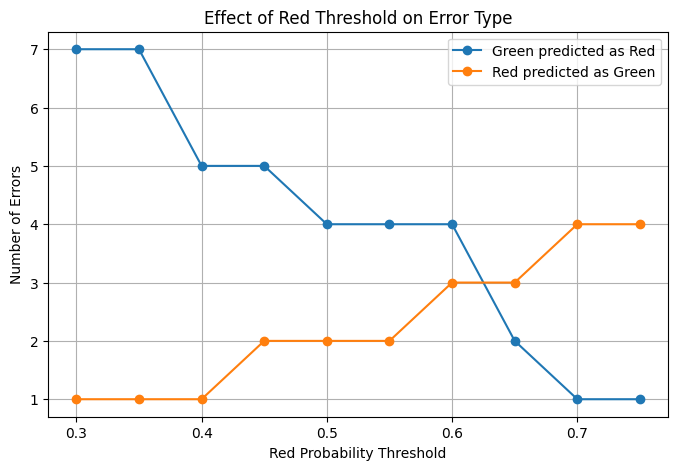

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["Red Threshold"],
    threshold_df["Green predicted as Red"],
    marker="o",
    label="Green predicted as Red"
)

plt.plot(
    threshold_df["Red Threshold"],
    threshold_df["Red predicted as Green"],
    marker="o",
    label="Red predicted as Green"
)

plt.title("Effect of Red Threshold on Error Type")
plt.xlabel("Red Probability Threshold")
plt.ylabel("Number of Errors")
plt.legend()
plt.grid(True)
plt.show()

Classification report and confusion matrix

In [32]:
print("Classification report after threshold tuning:")
print(classification_report(
    y_test_true,
    y_test_pred_threshold,
    target_names=class_names
))

Classification report after threshold tuning:
              precision    recall  f1-score   support

       Green       0.99      0.98      0.99       195
         Red       0.98      0.99      0.99       178

    accuracy                           0.99       373
   macro avg       0.99      0.99      0.99       373
weighted avg       0.99      0.99      0.99       373



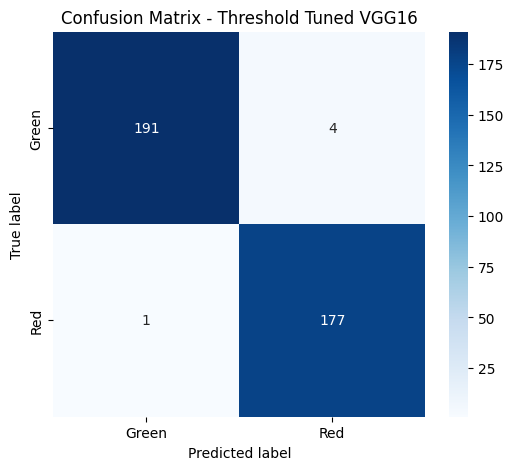

In [33]:
import seaborn as sns

cm_threshold = confusion_matrix(y_test_true, y_test_pred_threshold)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_threshold,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Threshold Tuned VGG16")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

## 10. Compare All Models

In [41]:
comparison_df = pd.DataFrame({
    'Model': [
        'Model 1: Frozen VGG16 + Data Augmentation',
        'Model 2: Regularised VGG16',
        'Model 3: Classification threshold tuning VGG16'
    ],
    'Test Accuracy': [model_1_acc, model_2_acc, threshold_test_accuracy],
})

comparison_df

,Model,Test Accuracy
0,Model 1: Frozen VGG16 + Data Augmentation,0.978552
1,Model 2: Regularised VGG16,0.989276
2,Model 3: Classification threshold tuning VGG16,0.986595


In [42]:
comparison_df.to_csv('model_comparison_results.csv', index=False)
print('Saved: model_comparison_results.csv')

Saved: model_comparison_results.csv


## 11. Five Unseen Test Image Predictions

Phone images batch shape: (5, 224, 224, 3)


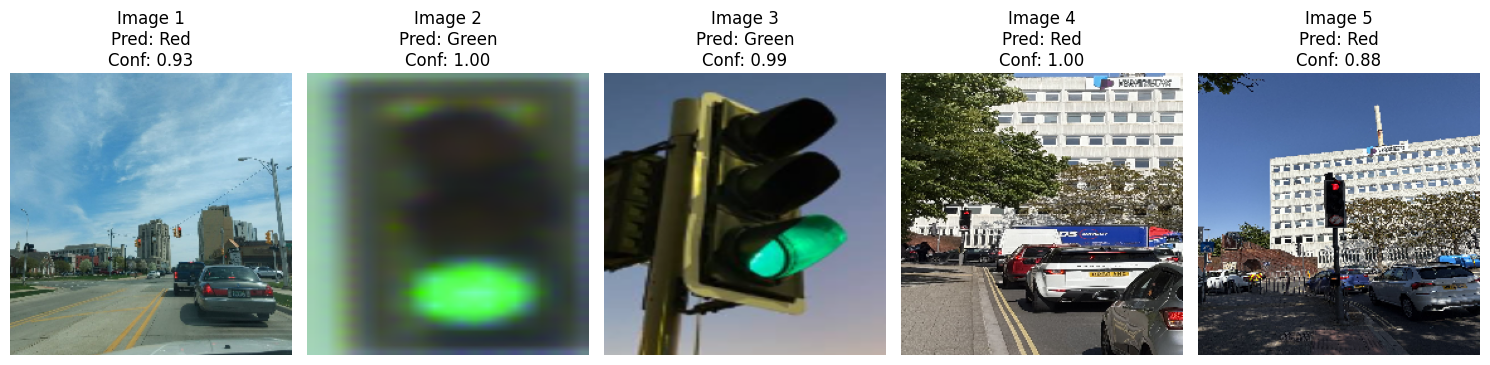

,Image Number,Image Path,Predicted Label,Confidence,Green Probability,Red Probability
0,1,phone_test_images/1000s.jpg,Red,0.9338,0.0662,0.9338
1,2,phone_test_images/106844_signal_0.png,Green,0.9981,0.9981,0.0019
2,3,phone_test_images/18.png,Green,0.9892,0.9892,0.0108
3,4,phone_test_images/IMG_2583.jpg,Red,0.9970,0.0030,0.9970
4,5,phone_test_images/IMG_2589.jpg,Red,0.8777,0.1223,0.8777


In [67]:
PHONE_IMAGE_FOLDER = "phone_test_images"

phone_image_paths = [
    os.path.join(PHONE_IMAGE_FOLDER, fname)
    for fname in sorted(os.listdir(PHONE_IMAGE_FOLDER))
    if fname.lower().endswith((".jpg", ".jpeg", ".png"))
]

phone_image_paths = phone_image_paths[:5]

phone_images = []

for img_path in phone_image_paths:
    img = cv2.imread(img_path)

    if img is None:
        print(f"Could not read image: {img_path}")
        continue

    # OpenCV loads BGR, convert to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize to match model input
    img = cv2.resize(img, (224, 224))

    img = img.astype("float32")

    phone_images.append(img)

phone_images = np.array(phone_images)

print("Phone images batch shape:", phone_images.shape)

best_model = model_2

prediction_probs = best_model.predict(phone_images, verbose=0)
predicted_classes = np.argmax(prediction_probs, axis=1)

plt.figure(figsize=(15, 6))
five_predictions = []

for i, img_path in enumerate(phone_image_paths):
    predicted_label = class_names[predicted_classes[i]]
    confidence = prediction_probs[i][predicted_classes[i]]

    five_predictions.append({
        "Image Number": i + 1,
        "Image Path": img_path,
        "Predicted Label": predicted_label,
        "Confidence": round(float(confidence), 4),
        "Green Probability": round(float(prediction_probs[i][0]), 4),
        "Red Probability": round(float(prediction_probs[i][1]), 4)
    })

    plt.subplot(1, 5, i + 1)

    # Convert back to uint8 for display
    plt.imshow(phone_images[i].astype("uint8"))

    plt.title(
        f"Image {i + 1}\n"
        f"Pred: {predicted_label}\n"
        f"Conf: {confidence:.2f}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

five_predictions_df = pd.DataFrame(five_predictions)
five_predictions_df

## 12. Save Best Model

In [68]:
best_model.save('traffic_light_vgg16_best_model.keras')
print('Saved: traffic_light_vgg16_best_model.keras')

Saved: traffic_light_vgg16_best_model.keras
